### Fashion-MNIST Classifier using LeNet-5

In [56]:
import torch
import torchvision
from torch import nn
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

In [57]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(), 
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10)
)

shape test:

In [58]:
X = torch.randn((1, 1, 28, 28), dtype=torch.float32, requires_grad=False)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
ReLU output shape: 	 torch.Size([1, 6, 28, 28])
MaxPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
ReLU output shape: 	 torch.Size([1, 16, 10, 10])
MaxPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
ReLU output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
ReLU output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [59]:
# 先用 ToTensor 加载，计算均值和标准差
tmp_data = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=transforms.ToTensor(), download=True)
tmp_loader = data.DataLoader(tmp_data, batch_size=len(tmp_data))
all_images, _ = next(iter(tmp_loader))          # shape: (60000, 1, 28, 28)
dt_mean = all_images.mean().item()
dt_std = all_images.std().item()
print(f'mean: {dt_mean:.4f}, std: {dt_std:.4f}')

# 用计算出的统计量构建标准化 transform
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[dt_mean], std=[dt_std])
])
mnist_data = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=trans, download=True)
len(mnist_data), len(mnist_test)

mean: 0.2860, std: 0.3530


(60000, 10000)

In [60]:
batch_size = 256
dataloader = data.DataLoader(mnist_data, batch_size=batch_size, shuffle=True)
testloader = data.DataLoader(mnist_test, batch_size=batch_size, shuffle=True)
feature, label = next(iter(dataloader))
feature.shape, label.shape

(torch.Size([256, 1, 28, 28]), torch.Size([256]))

In [61]:
class Accumulator:
    """Accumulator class for accumulating multiple scalar values."""

    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, key):
        return self.data[key]


def accuracy(y_hat, y):
    """Calculate the number of correct predictions.

    Args:
        y_hat: Model predictions with shape (batch_size, num_classes)
        y: Ground truth labels with shape (batch_size,)

    Returns:
        float: Number of correct predictions
    """
    y_hat = y_hat.argmax(axis=1)
    cmp = y_hat == y
    return cmp.float().sum().item()


def evaluator(net, test_iter, device=None):
    """Evaluate model accuracy on the test set.

    Args:
        net: Neural network model
        test_iter: Test data iterator

    Returns:
        float: Accuracy on the test set
    """
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = device = next(net.parameters()).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in test_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [62]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.kaiming_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    num_batches = len(train_iter)
    train_acc, test_acc = [], []
    cnt = 1
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
        train_acc.append(metric[1] / metric[2])
        test_acc.append(evaluator(net, test_iter))
        print(f'current epoch {cnt}: train acc {train_acc[-1]}, test acc {test_acc[-1]}')
        cnt += 1
    print(f'best train acc {max(train_acc):.5f}, ', f'best test acc {max(test_acc):.5f}')
    return train_acc, test_acc

training on mps
current epoch 1: train acc 0.7718666666666667, test acc 0.838
current epoch 2: train acc 0.8596333333333334, test acc 0.8541
current epoch 3: train acc 0.8762666666666666, test acc 0.8769
current epoch 4: train acc 0.8854833333333333, test acc 0.8751
current epoch 5: train acc 0.8946, test acc 0.8844
current epoch 6: train acc 0.9, test acc 0.8865
current epoch 7: train acc 0.9047, test acc 0.8919
current epoch 8: train acc 0.9099, test acc 0.8933
current epoch 9: train acc 0.9136833333333333, test acc 0.8973
current epoch 10: train acc 0.9174333333333333, test acc 0.8964
current epoch 11: train acc 0.9209666666666667, test acc 0.8936
current epoch 12: train acc 0.9249166666666667, test acc 0.9001
current epoch 13: train acc 0.9279333333333334, test acc 0.8958
current epoch 14: train acc 0.9310333333333334, test acc 0.8975
current epoch 15: train acc 0.9336333333333333, test acc 0.8998
current epoch 16: train acc 0.93645, test acc 0.8974
current epoch 17: train acc 0.93

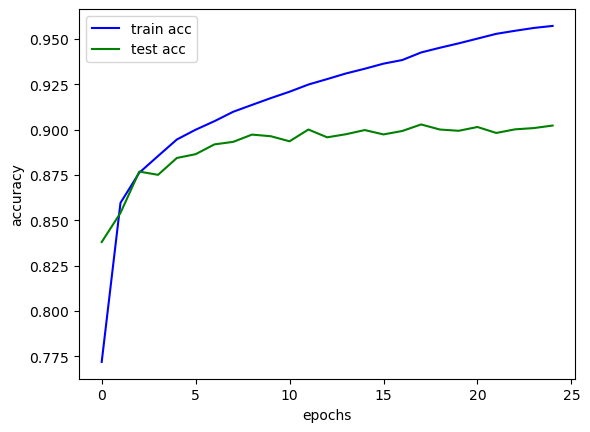

In [63]:
def try_gpu():
    """优先 CUDA, 其次 MPS, 最后 CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

lr, epochs = 0.001, 25
train_acc, test_acc = train_ch6(net, dataloader, testloader, epochs, lr, try_gpu())

fig, ax = plt.subplots()
ax.set_xlabel("epochs")
ax.set_ylabel("accuracy")
ax.plot(range(epochs), train_acc, color='b', label='train acc')
ax.plot(range(epochs), test_acc, color='g', label='test acc')
ax.legend()
fig.savefig('./pics/LeNet.png')